# AI-Powered Supplier Risk & Performance Analytics

**Domain:** Manufacturing & Supply Chain  
**Role Perspective:** 20-year Senior Data Scientist / AI Engineer  
**Dataset:** `supplier_risk.csv`

## Project Objective
Build a supplier risk analytics workflow to identify high-risk suppliers, understand key risk drivers, prepare dashboard-ready outputs, and train a machine learning model to predict supplier risk category.

## Business Questions
1. What percentage of suppliers/records are high risk?
2. Is supplier risk increasing or decreasing by year?
3. Which supplier performance factors drive high risk?
4. Which suppliers should be placed on a management watchlist?
5. Can we predict supplier risk using supplier performance metrics?

In [1]:
# =========================================================
# 1. Import Libraries
# =========================================================

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

Keep the CSV file in the same folder as this notebook. If you are using Google Colab or another environment, update the file path accordingly.

In [2]:
# =========================================================
# 2. Load Data
# =========================================================

possible_paths = [
    "supplier_risk.csv",
    "/mnt/data/supplier_risk.csv"
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("supplier_risk.csv not found. Please place it in the notebook folder.")

df = pd.read_csv(data_path)

print("Dataset loaded from:", data_path)
print("Shape:", df.shape)
df.head()

Dataset loaded from: supplier_risk.csv
Shape: (1800, 12)


,Supplier_ID,Year,Financial_Stability_Score,Delivery_Performance_Score,Quality_Compliance_Score,Regulatory_Adherence_Score,Sustainability_Score,Past_Risk_Level,ERP_Transactions,Incidents_Count,MCDM_Score,Risk_Category
0,52,2025,0.43,0.87,0.80,0.78,0.37,0.46,422,3,0.66,Medium
1,24,2023,0.31,0.98,0.92,0.68,0.43,0.18,363,11,0.67,Medium
2,89,2021,0.67,0.64,0.52,0.99,0.46,0.09,495,18,0.66,Medium
3,55,2024,0.71,0.43,0.80,0.67,0.35,0.95,365,13,0.62,Medium
4,9,2022,0.37,0.81,0.72,0.65,0.65,0.03,255,16,0.62,Medium


## 3. Data Understanding

This section checks columns, data types, missing values, duplicates, and basic statistical summary.

In [3]:
# =========================================================
# 3. Data Understanding
# =========================================================

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Unique Suppliers:", df['Supplier_ID'].nunique())
print("Year Range:", df['Year'].min(), "to", df['Year'].max())
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data_Type"))

Rows: 1800
Columns: 12
Unique Suppliers: 100
Year Range: 2021 to 2025

Column Names:
['Supplier_ID', 'Year', 'Financial_Stability_Score', 'Delivery_Performance_Score', 'Quality_Compliance_Score', 'Regulatory_Adherence_Score', 'Sustainability_Score', 'Past_Risk_Level', 'ERP_Transactions', 'Incidents_Count', 'MCDM_Score', 'Risk_Category']

Data Types:


,Data_Type
Supplier_ID,int64
Year,int64
Financial_Stability_Score,float64
Delivery_Performance_Score,float64
Quality_Compliance_Score,float64
Regulatory_Adherence_Score,float64
Sustainability_Score,float64
Past_Risk_Level,float64
ERP_Transactions,int64
Incidents_Count,int64


In [4]:
# Missing values and duplicate checks
missing_summary = df.isnull().sum().to_frame("Missing_Count")
missing_summary["Missing_%"] = (missing_summary["Missing_Count"] / len(df) * 100).round(2)

duplicate_count = df.duplicated().sum()

print("Total Missing Values:", int(missing_summary["Missing_Count"].sum()))
print("Duplicate Rows:", duplicate_count)
display(missing_summary)

Total Missing Values: 0
Duplicate Rows: 0


,Missing_Count,Missing_%
Supplier_ID,0,0.0
Year,0,0.0
Financial_Stability_Score,0,0.0
Delivery_Performance_Score,0,0.0
Quality_Compliance_Score,0,0.0
Regulatory_Adherence_Score,0,0.0
Sustainability_Score,0,0.0
Past_Risk_Level,0,0.0
ERP_Transactions,0,0.0
Incidents_Count,0,0.0


In [5]:
# Numerical summary
summary_stats = df.describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
Supplier_ID,1800.0,49.173889,28.191087,1.00,25.00,49.00,73.00,100.00
Year,1800.0,2022.958333,1.420464,2021.00,2022.00,2023.00,2024.00,2025.00
Financial_Stability_Score,1800.0,0.647500,0.199539,0.30,0.47,0.65,0.81,1.00
Delivery_Performance_Score,1800.0,0.699083,0.174938,0.40,0.54,0.70,0.85,1.00
Quality_Compliance_Score,1800.0,0.746772,0.140464,0.50,0.63,0.74,0.87,1.00
Regulatory_Adherence_Score,1800.0,0.796194,0.115470,0.60,0.70,0.80,0.89,1.00
Sustainability_Score,1800.0,0.646228,0.202019,0.30,0.47,0.64,0.82,1.00
Past_Risk_Level,1800.0,0.494578,0.291539,0.00,0.24,0.50,0.74,1.00
ERP_Transactions,1800.0,270.117222,130.734123,50.00,158.00,264.00,385.00,499.00
Incidents_Count,1800.0,9.601111,5.758605,0.00,5.00,10.00,15.00,19.00


## 4. Key Performance Indicators

These KPIs are useful for the first page of a Power BI dashboard.

In [6]:
# =========================================================
# 4. KPI Summary
# =========================================================

total_records = len(df)
total_suppliers = df['Supplier_ID'].nunique()
year_min, year_max = df['Year'].min(), df['Year'].max()
total_incidents = df['Incidents_Count'].sum()
avg_incidents = df['Incidents_Count'].mean()
avg_mcdm = df['MCDM_Score'].mean()
high_risk_count = (df['Risk_Category'] == 'High').sum()
medium_risk_count = (df['Risk_Category'] == 'Medium').sum()
high_risk_pct = high_risk_count / total_records * 100

kpi_df = pd.DataFrame({
    "KPI": [
        "Total Records", "Total Suppliers", "Year Range", "High Risk Records",
        "Medium Risk Records", "High Risk %", "Total Incidents", "Avg Incidents/Record", "Avg MCDM Score"
    ],
    "Value": [
        total_records, total_suppliers, f"{year_min}-{year_max}", high_risk_count,
        medium_risk_count, f"{high_risk_pct:.2f}%", total_incidents, f"{avg_incidents:.2f}", f"{avg_mcdm:.3f}"
    ]
})

kpi_df

,KPI,Value
0,Total Records,1800
1,Total Suppliers,100
2,Year Range,2021-2025
3,High Risk Records,884
4,Medium Risk Records,916
5,High Risk %,49.11%
6,Total Incidents,17282
7,Avg Incidents/Record,9.60
8,Avg MCDM Score,0.703


## 5. Risk Category Distribution

The target variable is `Risk_Category`. We will check whether the dataset is balanced.

In [7]:
# =========================================================
# 5. Risk Distribution
# =========================================================

risk_distribution = df['Risk_Category'].value_counts().reset_index()
risk_distribution.columns = ['Risk_Category', 'Count']
risk_distribution['Percentage'] = (risk_distribution['Count'] / len(df) * 100).round(2)
risk_distribution

,Risk_Category,Count,Percentage
0,Medium,916,50.89
1,High,884,49.11


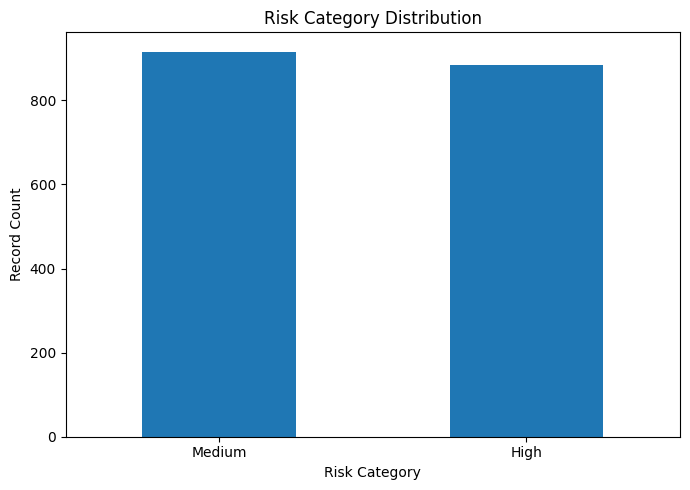

In [8]:
plt.figure(figsize=(7, 5))
df['Risk_Category'].value_counts().plot(kind='bar')
plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Record Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Senior Insight
The data is almost balanced between **High Risk** and **Medium Risk** records. This is useful for classification modelling because the target classes are not extremely imbalanced.

## 6. Year-wise Risk Trend

This helps management understand whether supplier risk is improving or worsening over time.

In [9]:
# =========================================================
# 6. Year-wise Risk Trend
# =========================================================

year_risk = pd.crosstab(df['Year'], df['Risk_Category'])
year_risk['Total'] = year_risk.sum(axis=1)
year_risk['High_Risk_%'] = (year_risk.get('High', 0) / year_risk['Total'] * 100).round(2)
year_risk

Risk_Category,High,Medium,Total,High_Risk_%
Year,,,,
2021,182,195,377,48.28
2022,171,203,374,45.72
2023,171,174,345,49.57
2024,172,183,355,48.45
2025,188,161,349,53.87


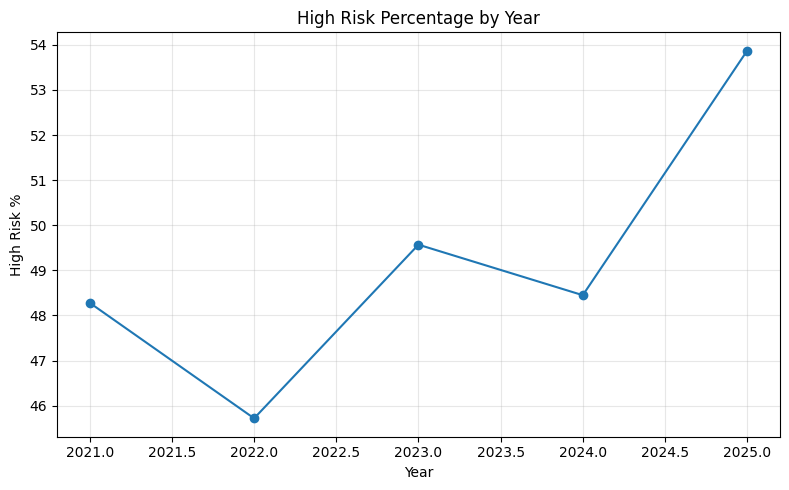

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(year_risk.index, year_risk['High_Risk_%'], marker='o')
plt.title("High Risk Percentage by Year")
plt.xlabel("Year")
plt.ylabel("High Risk %")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

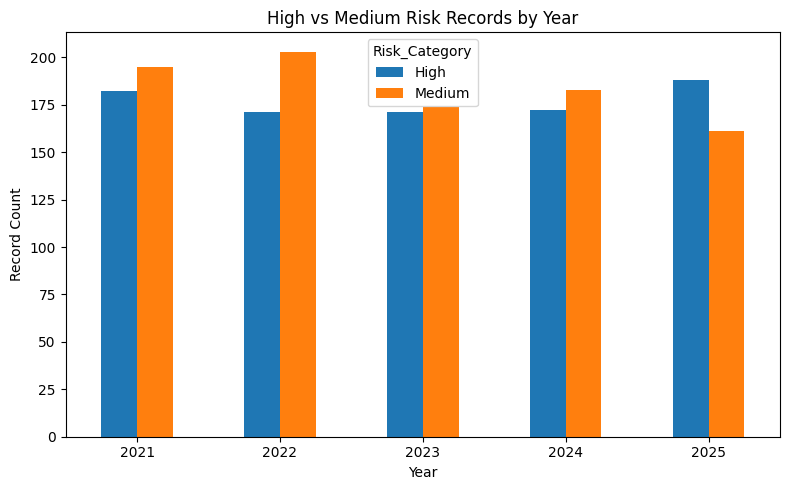

In [11]:
plt.figure(figsize=(8, 5))
year_risk[['High', 'Medium']].plot(kind='bar', figsize=(8, 5))
plt.title("High vs Medium Risk Records by Year")
plt.xlabel("Year")
plt.ylabel("Record Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Senior Insight
The highest high-risk percentage appears in the latest year. This is important because it may indicate rising supply chain exposure, deteriorating supplier performance, or stricter scoring thresholds.

## 7. Score Analysis by Risk Category

We compare the average values of key supplier performance metrics for `High` and `Medium` risk suppliers.

In [12]:
# =========================================================
# 7. Score Analysis by Risk Category
# =========================================================

score_columns = [
    'Financial_Stability_Score',
    'Delivery_Performance_Score',
    'Quality_Compliance_Score',
    'Regulatory_Adherence_Score',
    'Sustainability_Score',
    'Past_Risk_Level',
    'ERP_Transactions',
    'Incidents_Count',
    'MCDM_Score'
]

risk_score_summary = df.groupby('Risk_Category')[score_columns].mean().round(3)
risk_score_summary

,Financial_Stability_Score,Delivery_Performance_Score,Quality_Compliance_Score,Regulatory_Adherence_Score,Sustainability_Score,Past_Risk_Level,ERP_Transactions,Incidents_Count,MCDM_Score
Risk_Category,,,,,,,,,
High,0.769,0.778,0.782,0.813,0.692,0.501,267.963,9.488,0.773
Medium,0.531,0.623,0.713,0.780,0.602,0.489,272.197,9.711,0.635


<Figure size 700x500 with 0 Axes>

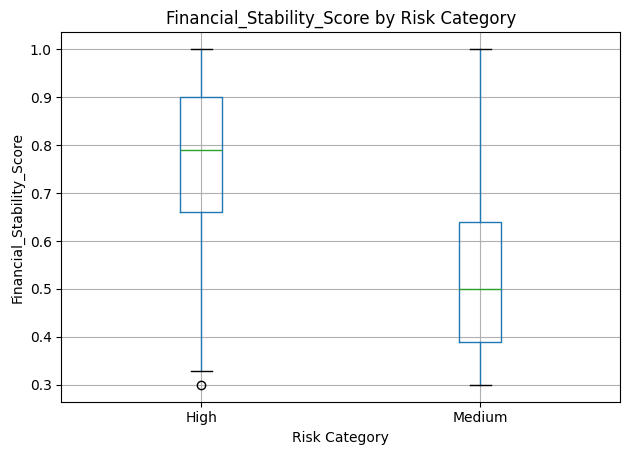

<Figure size 700x500 with 0 Axes>

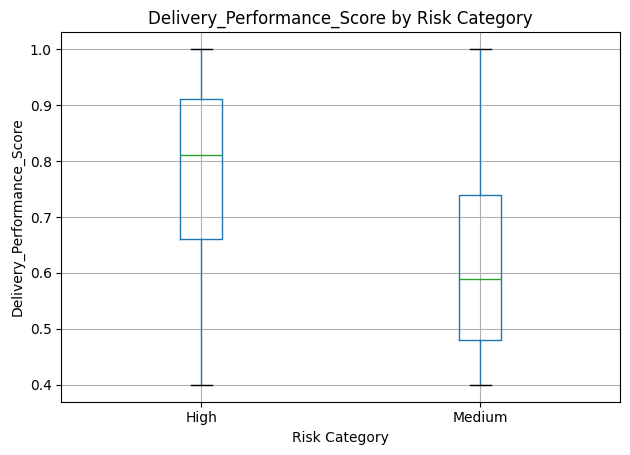

<Figure size 700x500 with 0 Axes>

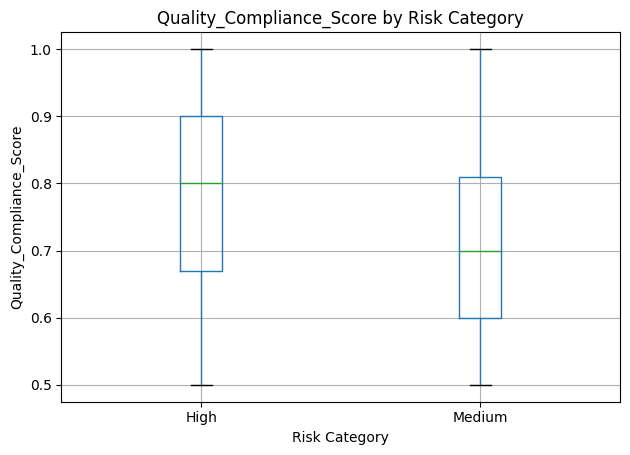

<Figure size 700x500 with 0 Axes>

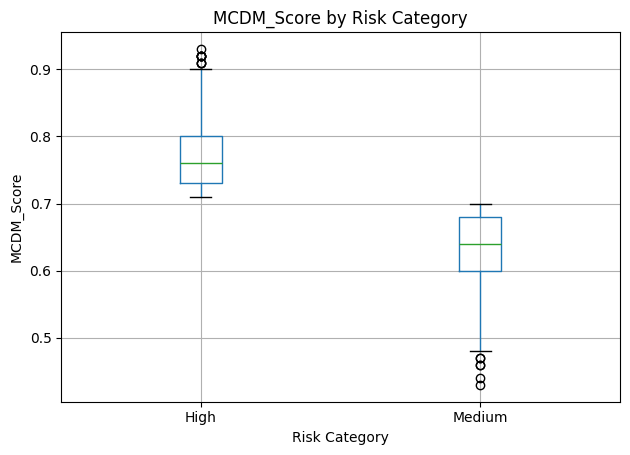

In [13]:
# Compare selected scores by risk category using boxplots
selected_scores = [
    'Financial_Stability_Score',
    'Delivery_Performance_Score',
    'Quality_Compliance_Score',
    'MCDM_Score'
]

for col in selected_scores:
    plt.figure(figsize=(7, 5))
    df.boxplot(column=col, by='Risk_Category')
    plt.title(f"{col} by Risk Category")
    plt.suptitle("")
    plt.xlabel("Risk Category")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 8. Correlation Analysis

Correlation shows how strongly numerical variables move together. Here, we focus especially on relation with `MCDM_Score`.

In [14]:
# =========================================================
# 8. Correlation Analysis
# =========================================================

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr().round(3)

corr_with_mcdm = corr['MCDM_Score'].sort_values(ascending=False).to_frame('Correlation_with_MCDM')
corr_with_mcdm

,Correlation_with_MCDM
MCDM_Score,1.000
Financial_Stability_Score,0.715
Delivery_Performance_Score,0.554
Quality_Compliance_Score,0.334
Sustainability_Score,0.277
Regulatory_Adherence_Score,0.192
Year,0.041
Incidents_Count,-0.000
Past_Risk_Level,-0.002
Supplier_ID,-0.005


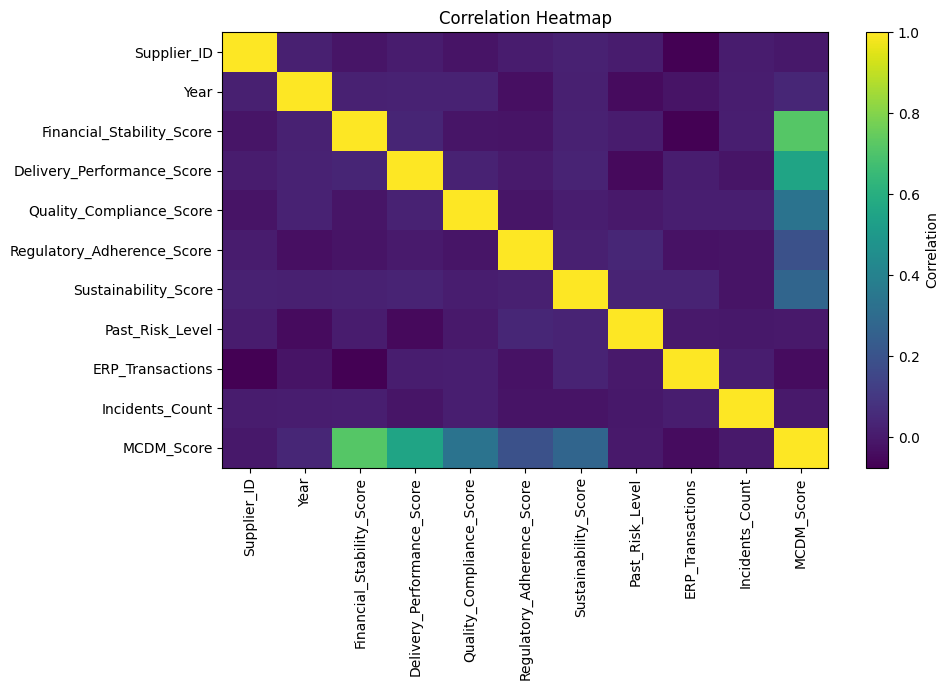

In [15]:
plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Senior Insight
If `Risk_Category` is mainly created from `MCDM_Score`, the ML model will easily predict risk. For a stronger real-world AI case study, you can later create a future-risk label using next-year incidents or score deterioration.

## 9. Supplier-Level Scorecard

Management usually does not want row-level data only. They need supplier-level aggregation. This scorecard summarizes each supplier's historical risk and performance.

In [16]:
# =========================================================
# 9. Supplier-Level Scorecard
# =========================================================

supplier_scorecard = df.groupby('Supplier_ID').agg(
    Records=('Supplier_ID', 'count'),
    Active_Years=('Year', 'nunique'),
    Avg_MCDM=('MCDM_Score', 'mean'),
    High_Risk_Count=('Risk_Category', lambda x: (x == 'High').sum()),
    High_Risk_Pct=('Risk_Category', lambda x: (x == 'High').mean() * 100),
    Total_Incidents=('Incidents_Count', 'sum'),
    Avg_Incidents=('Incidents_Count', 'mean'),
    Avg_Financial=('Financial_Stability_Score', 'mean'),
    Avg_Delivery=('Delivery_Performance_Score', 'mean'),
    Avg_Quality=('Quality_Compliance_Score', 'mean'),
    Avg_Regulatory=('Regulatory_Adherence_Score', 'mean'),
    Avg_Sustainability=('Sustainability_Score', 'mean'),
    Avg_ERP=('ERP_Transactions', 'mean')
).reset_index()

# Custom senior risk index for management prioritization
supplier_scorecard['Risk_Index'] = (
    0.50 * supplier_scorecard['Avg_MCDM'] +
    0.25 * (supplier_scorecard['High_Risk_Pct'] / 100) +
    0.25 * (supplier_scorecard['Avg_Incidents'] / supplier_scorecard['Avg_Incidents'].max())
)

supplier_scorecard = supplier_scorecard.sort_values('Risk_Index', ascending=False)
supplier_scorecard.head(10).round(3)

,Supplier_ID,Records,Active_Years,Avg_MCDM,High_Risk_Count,High_Risk_Pct,Total_Incidents,Avg_Incidents,Avg_Financial,Avg_Delivery,Avg_Quality,Avg_Regulatory,Avg_Sustainability,Avg_ERP,Risk_Index
25,26,18,5,0.748,14,77.778,176,9.778,0.766,0.707,0.766,0.798,0.683,292.500,0.736
33,34,14,4,0.754,10,71.429,144,10.286,0.754,0.793,0.756,0.783,0.631,288.357,0.731
62,63,22,5,0.717,14,63.636,263,11.955,0.675,0.729,0.698,0.815,0.695,261.273,0.722
96,97,16,5,0.754,11,68.750,161,10.062,0.739,0.788,0.721,0.818,0.697,238.188,0.721
30,31,11,4,0.712,5,45.455,161,14.636,0.594,0.784,0.741,0.809,0.685,370.727,0.720
1,2,19,5,0.719,14,73.684,192,10.105,0.684,0.724,0.774,0.780,0.609,345.421,0.717
72,73,11,4,0.736,8,72.727,106,9.636,0.734,0.731,0.738,0.814,0.635,194.000,0.715
67,68,20,5,0.730,12,60.000,233,11.650,0.690,0.706,0.806,0.777,0.684,260.450,0.714
12,13,16,5,0.729,10,62.500,180,11.250,0.662,0.744,0.802,0.798,0.645,164.625,0.713
2,3,24,5,0.710,14,58.333,292,12.167,0.642,0.732,0.778,0.760,0.637,252.375,0.708


In [17]:
# Supplier Watchlist: top 15 suppliers by custom risk index
supplier_watchlist = supplier_scorecard.head(15).copy()
supplier_watchlist.round(3)

,Supplier_ID,Records,Active_Years,Avg_MCDM,High_Risk_Count,High_Risk_Pct,Total_Incidents,Avg_Incidents,Avg_Financial,Avg_Delivery,Avg_Quality,Avg_Regulatory,Avg_Sustainability,Avg_ERP,Risk_Index
25,26,18,5,0.748,14,77.778,176,9.778,0.766,0.707,0.766,0.798,0.683,292.500,0.736
33,34,14,4,0.754,10,71.429,144,10.286,0.754,0.793,0.756,0.783,0.631,288.357,0.731
62,63,22,5,0.717,14,63.636,263,11.955,0.675,0.729,0.698,0.815,0.695,261.273,0.722
96,97,16,5,0.754,11,68.750,161,10.062,0.739,0.788,0.721,0.818,0.697,238.188,0.721
30,31,11,4,0.712,5,45.455,161,14.636,0.594,0.784,0.741,0.809,0.685,370.727,0.720
1,2,19,5,0.719,14,73.684,192,10.105,0.684,0.724,0.774,0.780,0.609,345.421,0.717
72,73,11,4,0.736,8,72.727,106,9.636,0.734,0.731,0.738,0.814,0.635,194.000,0.715
67,68,20,5,0.730,12,60.000,233,11.650,0.690,0.706,0.806,0.777,0.684,260.450,0.714
12,13,16,5,0.729,10,62.500,180,11.250,0.662,0.744,0.802,0.798,0.645,164.625,0.713
2,3,24,5,0.710,14,58.333,292,12.167,0.642,0.732,0.778,0.760,0.637,252.375,0.708


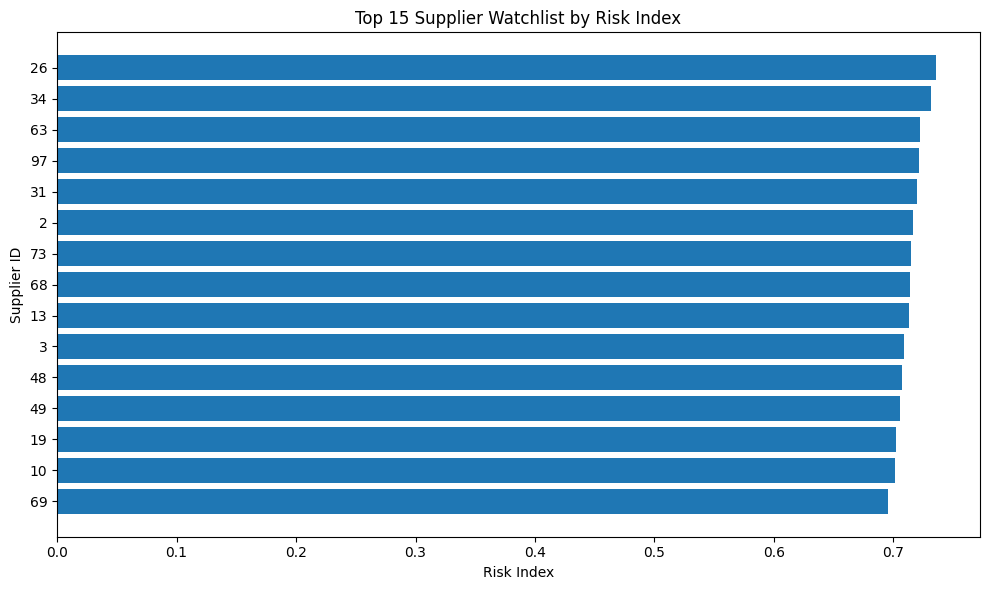

In [18]:
plt.figure(figsize=(10, 6))
watch = supplier_watchlist.sort_values('Risk_Index', ascending=True)
plt.barh(watch['Supplier_ID'].astype(str), watch['Risk_Index'])
plt.title("Top 15 Supplier Watchlist by Risk Index")
plt.xlabel("Risk Index")
plt.ylabel("Supplier ID")
plt.tight_layout()
plt.show()

### Supplier Watchlist Interpretation
Suppliers at the top of this list should be reviewed first. Typical actions include quality audit, contract review, backup supplier planning, and monitoring of delivery performance.

## 10. Incident Analysis

Incidents are important because they represent actual operational issues. A supplier can have a good score but still create risk if incident frequency is high.

In [19]:
# =========================================================
# 10. Incident Analysis
# =========================================================

incident_kpi = pd.DataFrame({
    'Metric': ['Total Incidents', 'Average Incidents per Record', 'Maximum Incidents in One Record'],
    'Value': [df['Incidents_Count'].sum(), round(df['Incidents_Count'].mean(), 2), df['Incidents_Count'].max()]
})
incident_kpi

,Metric,Value
0,Total Incidents,17282.0
1,Average Incidents per Record,9.6
2,Maximum Incidents in One Record,19.0


In [20]:
top_incident_suppliers = df.groupby('Supplier_ID')['Incidents_Count'].sum().sort_values(ascending=False).head(15).reset_index()
top_incident_suppliers.columns = ['Supplier_ID', 'Total_Incidents']
top_incident_suppliers

,Supplier_ID,Total_Incidents
0,3,292
1,19,282
2,23,275
3,76,275
4,62,270
5,36,270
6,55,267
7,54,265
8,63,263
9,21,258


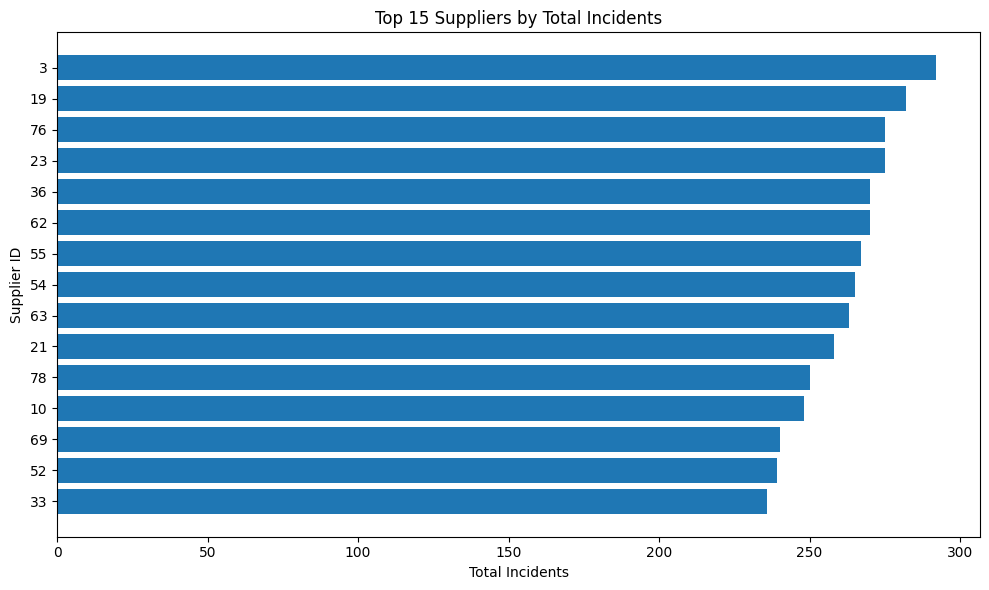

In [21]:
plt.figure(figsize=(10, 6))
plot_data = top_incident_suppliers.sort_values('Total_Incidents', ascending=True)
plt.barh(plot_data['Supplier_ID'].astype(str), plot_data['Total_Incidents'])
plt.title("Top 15 Suppliers by Total Incidents")
plt.xlabel("Total Incidents")
plt.ylabel("Supplier ID")
plt.tight_layout()
plt.show()

## 11. Machine Learning: Risk Category Prediction

We will train a Random Forest classifier to predict whether a supplier record is `High` risk or `Medium` risk.

### Target
- `High` = 1
- `Medium` = 0

### Features
We intentionally exclude `MCDM_Score` from the model because it is likely used to create `Risk_Category`. This helps avoid target leakage and makes the model more realistic.

In [22]:
# =========================================================
# 11. Machine Learning Model
# =========================================================

features = [
    'Financial_Stability_Score',
    'Delivery_Performance_Score',
    'Quality_Compliance_Score',
    'Regulatory_Adherence_Score',
    'Sustainability_Score',
    'Past_Risk_Level',
    'ERP_Transactions',
    'Incidents_Count'
]

X = df[features]
y = (df['Risk_Category'] == 'High').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:, 1]

metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Value': [
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob)
    ]
})

metrics['Value'] = metrics['Value'].round(4)
metrics

,Metric,Value
0,Accuracy,0.9306
1,Precision,0.9368
2,Recall,0.9209
3,F1 Score,0.9288
4,ROC-AUC,0.9883


In [23]:
print(classification_report(y_test, pred, target_names=['Medium', 'High']))

              precision    recall  f1-score   support

      Medium       0.92      0.94      0.93       183
        High       0.94      0.92      0.93       177

    accuracy                           0.93       360
   macro avg       0.93      0.93      0.93       360
weighted avg       0.93      0.93      0.93       360



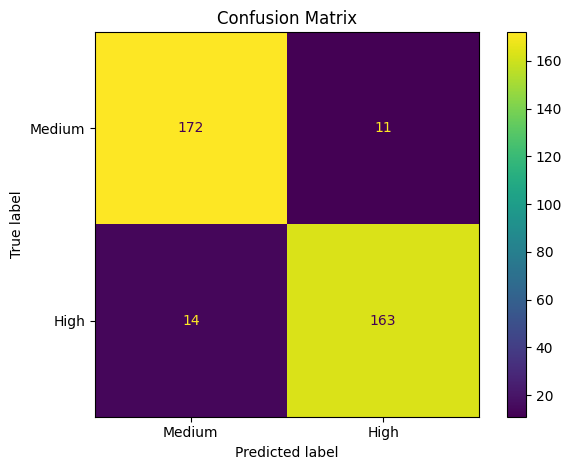

In [24]:
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Medium', 'High'])
disp.plot(values_format='d')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

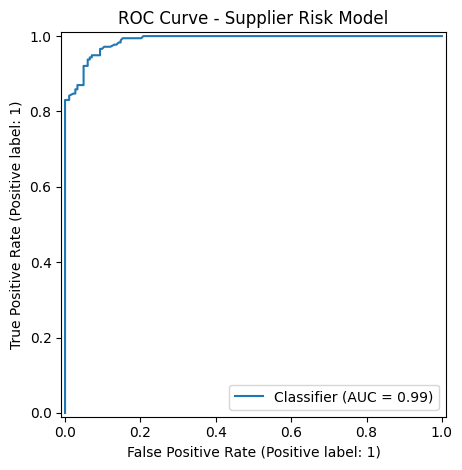

In [25]:
RocCurveDisplay.from_predictions(y_test, prob)
plt.title("ROC Curve - Supplier Risk Model")
plt.tight_layout()
plt.show()

## 12. Feature Importance

Feature importance explains which variables the model used most to identify high-risk suppliers.

In [26]:
# =========================================================
# 12. Feature Importance
# =========================================================

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance['Importance_%'] = (feature_importance['Importance'] * 100).round(2)
feature_importance

,Feature,Importance,Importance_%
0,Financial_Stability_Score,0.376071,37.61
1,Delivery_Performance_Score,0.231625,23.16
2,Quality_Compliance_Score,0.108101,10.81
4,Sustainability_Score,0.090152,9.02
3,Regulatory_Adherence_Score,0.063791,6.38
6,ERP_Transactions,0.049554,4.96
5,Past_Risk_Level,0.046511,4.65
7,Incidents_Count,0.034195,3.42


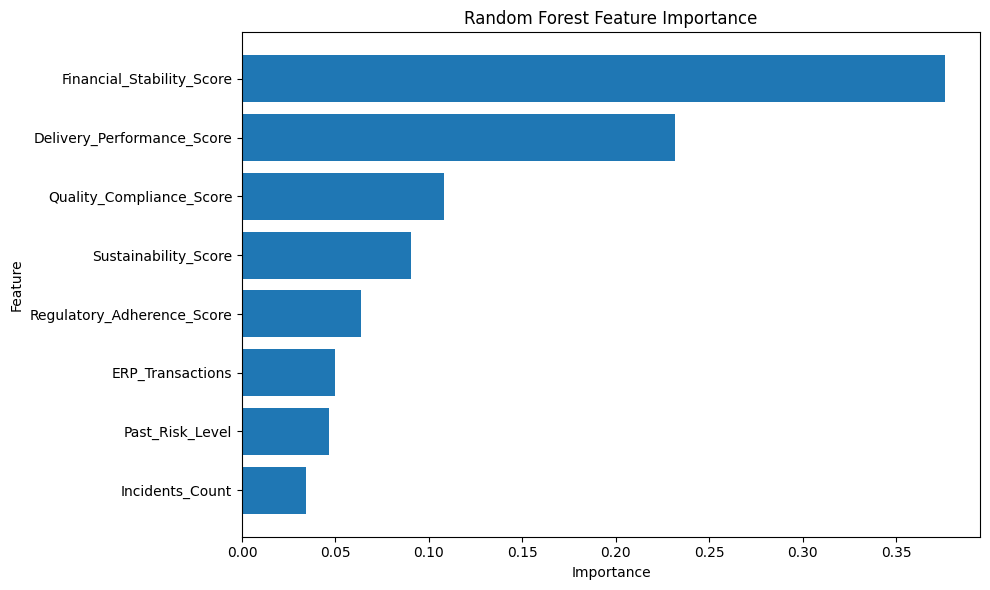

In [27]:
plt.figure(figsize=(10, 6))
plot_fi = feature_importance.sort_values('Importance', ascending=True)
plt.barh(plot_fi['Feature'], plot_fi['Importance'])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Senior Insight
If financial stability and delivery performance dominate the model, then procurement teams should focus on financial monitoring and delivery reliability. Incident count should still be tracked separately because real-world incidents can signal operational risk even when score-based risk is moderate.

## 13. Create Prediction Output for Power BI

This output can be imported into Power BI to create an AI prediction dashboard.

In [28]:
# =========================================================
# 13. Prediction Output
# =========================================================

prediction_df = df.copy()
prediction_df['Predicted_High_Risk_Probability'] = model.predict_proba(df[features])[:, 1]
prediction_df['Predicted_Risk_Category'] = np.where(
    prediction_df['Predicted_High_Risk_Probability'] >= 0.50,
    'High',
    'Medium'
)

# Business-friendly risk level from probability
prediction_df['AI_Risk_Level'] = pd.cut(
    prediction_df['Predicted_High_Risk_Probability'],
    bins=[0, 0.40, 0.70, 1.00],
    labels=['Low Monitoring', 'Medium Monitoring', 'High Monitoring'],
    include_lowest=True
)

prediction_df[['Supplier_ID', 'Year', 'Risk_Category', 'Predicted_Risk_Category', 'Predicted_High_Risk_Probability', 'AI_Risk_Level']].head()

,Supplier_ID,Year,Risk_Category,Predicted_Risk_Category,Predicted_High_Risk_Probability,AI_Risk_Level
0,52,2025,Medium,Medium,0.096667,Low Monitoring
1,24,2023,Medium,Medium,0.223333,Low Monitoring
2,89,2021,Medium,Medium,0.126667,Low Monitoring
3,55,2024,Medium,Medium,0.030000,Low Monitoring
4,9,2022,Medium,Medium,0.053333,Low Monitoring


## 14. Export Cleaned and Dashboard-Ready Files

The following CSV files are useful for Power BI, GitHub, and final project submission.

In [29]:
# =========================================================
# 14. Export Files
# =========================================================

output_dir = "supplier_risk_outputs"
os.makedirs(output_dir, exist_ok=True)

df.to_csv(os.path.join(output_dir, "supplier_risk_cleaned.csv"), index=False)
year_risk.to_csv(os.path.join(output_dir, "year_risk_summary.csv"))
supplier_scorecard.to_csv(os.path.join(output_dir, "supplier_scorecard.csv"), index=False)
supplier_watchlist.to_csv(os.path.join(output_dir, "supplier_watchlist.csv"), index=False)
feature_importance.to_csv(os.path.join(output_dir, "feature_importance.csv"), index=False)
prediction_df.to_csv(os.path.join(output_dir, "supplier_risk_predictions.csv"), index=False)
metrics.to_csv(os.path.join(output_dir, "model_metrics.csv"), index=False)

print("Files exported successfully to folder:", output_dir)
print(os.listdir(output_dir))

Files exported successfully to folder: supplier_risk_outputs
['supplier_risk_cleaned.csv', 'year_risk_summary.csv', 'supplier_scorecard.csv', 'supplier_watchlist.csv', 'feature_importance.csv', 'supplier_risk_predictions.csv', 'model_metrics.csv']


## 15. Final Business Recommendations

### 1. Create Supplier Watchlist
Prioritize suppliers with high `Risk_Index`, high incident count, and high historical high-risk percentage.

### 2. Monitor Financial Stability Closely
Financial stability is usually one of the strongest risk signals. Suppliers with deteriorating financial scores need early review.

### 3. Improve Delivery Performance Governance
Late deliveries and unstable delivery performance can create production stoppage. Track supplier SLA compliance monthly.

### 4. Do Not Depend Only on MCDM Score
The MCDM score is useful, but real-world risk should also include incidents, past risk, ERP transaction dependency, and year-over-year performance decline.

### 5. Build Future-Risk Model in Next Phase
For a stronger AI project, create a new target such as:

`Future_High_Risk = 1 if next year's MCDM score increases or incidents increase significantly`

This converts the project from simple classification into true predictive supplier risk forecasting.

# Project Conclusion

This notebook provides a complete supplier risk analytics workflow:

- Data quality validation
- KPI analysis
- Risk trend analysis
- Supplier scorecard
- Supplier watchlist
- Incident analysis
- Machine learning risk prediction
- Feature importance interpretation
- Power BI-ready CSV exports

This is suitable for a portfolio project titled:

## **AI-Powered Supplier Risk & Performance Analytics Dashboard**